# Gemini 3 with LangChain - Bootcamp

This notebook demonstrates all key features of Google's Gemini 3 model family using LangChain.

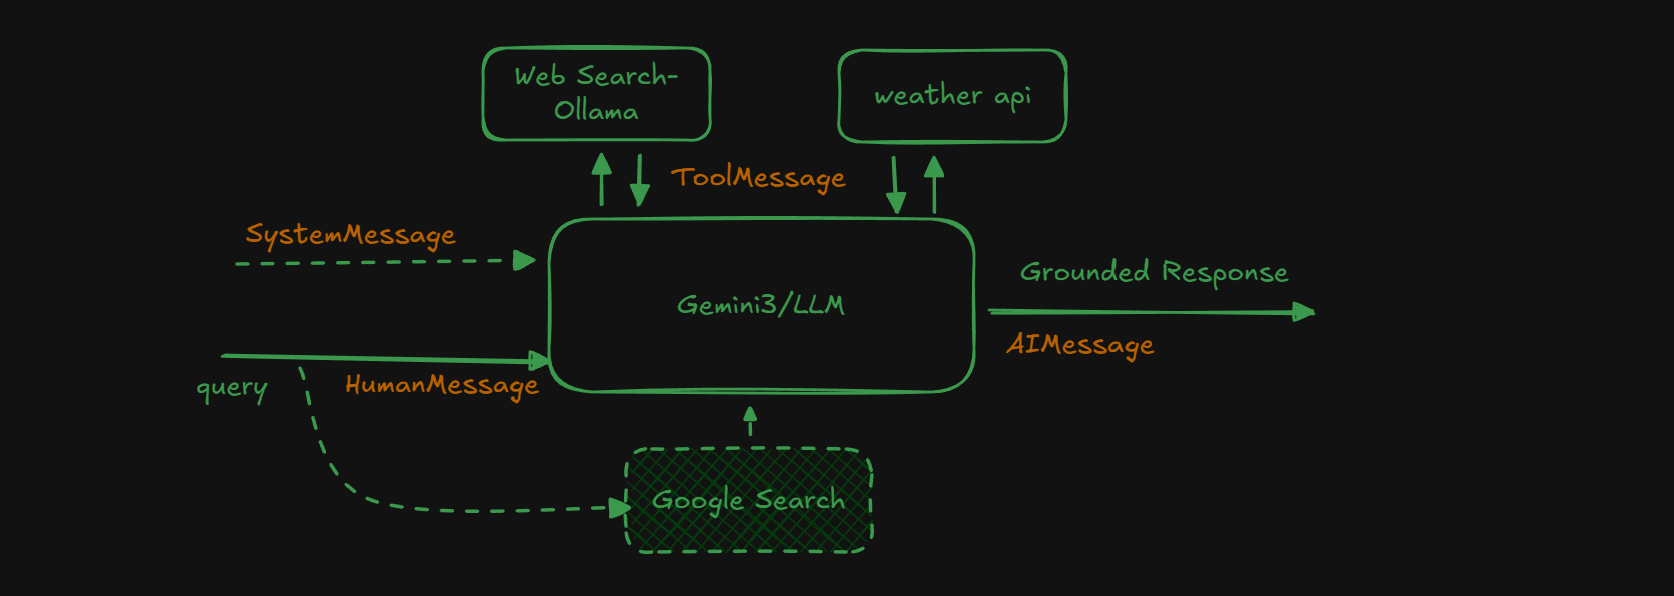

## Gemini 3 Overview

**Gemini 3 Pro** is Google's most intelligent model family, built on state-of-the-art reasoning capabilities.

### Key Features
- **Advanced Reasoning**: Dynamic thinking process with configurable thinking levels
- **1M Token Context**: Up to 1 million token input, 64k token output
- **Multimodal Excellence**: Images, PDFs, audio, video with granular resolution control
- **Knowledge Cutoff**: January 2025
- **Image Generation**: 4K resolution with grounded generation

### Model Variants

| Model | Context (In/Out) | Best For |
|-------|------------------|----------|
| `gemini-3-pro-preview` | 1M / 64k | Complex reasoning, coding, analysis |
| `gemini-3-pro-image-preview` | 65k / 32k | Image generation & editing |
| `gemini-2.5-flash` | 1M / 8k | Fast, cost-effective tasks |

### New Features in Gemini 3
1. **Thinking Level**: Control reasoning depth (`low` or `high`)
2. **Media Resolution**: Granular control per media type (`low`, `medium`, `high`, `ultra_high`)
3. **Temperature**: Keep at default 1.0 (changing can cause degraded performance)
4. **Thought Signatures**: Automatic reasoning context preservation

## Setup

Load environment variables for API authentication.

https://ai.google.dev/gemini-api/docs/pricing

In [1]:
from langfuse.langchain import CallbackHandler

from dotenv import load_dotenv
load_dotenv()

langfuse_handler = CallbackHandler()

In [ ]:
import os
# os.getenv("GOOGLE_API_KEY")

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage

## Basic Usage

Demonstrates basic message formats and response structures for both Gemini 3 and 2.5 models.

In [3]:
gemini3 = 'gemini-3-pro-preview'
gemini2 = 'gemini-2.5-flash'

system_msg = SystemMessage("You are a helpful AI Assistant")
query = HumanMessage("Explain the theory of reletivity in the simple terms")

messages = [system_msg, query]

In [4]:
# model = ChatGoogleGenerativeAI(model=gemini3)
model = ChatGoogleGenerativeAI(model=gemini2)
response = model.invoke(messages, config={"callbacks": [langfuse_handler]})

In [5]:
# print(response.text)

response.content

'The theory of relativity, developed by Albert Einstein, is actually two related theories: **Special Relativity** and **General Relativity**. Both fundamentally changed our understanding of space, time, gravity, and the universe.\n\nLet\'s break them down in simple terms:\n\n---\n\n### Part 1: Special Relativity (1905)\n\n**What it deals with:** Objects moving at a *constant speed* relative to each other (no acceleration).\n\n**The two big ideas:**\n\n1.  **The Principle of Relativity:** The laws of physics are the same for everyone, no matter how fast or in what direction they\'re moving, as long as they\'re moving at a constant speed.\n    *   **Simple Analogy:** Imagine you\'re in a perfectly smooth, windowless train car moving at a constant speed. You can\'t tell you\'re moving without looking outside. A ball you toss up will come straight back down, just as it would if the train were standing still. The laws of physics (like gravity affecting the ball) work the same way.\n\n2.  **

In [ ]:
response.content_blocks

In [ ]:
model = ChatGoogleGenerativeAI(model=gemini2)
response = model.invoke(messages, config={"callbacks": [langfuse_handler]})

In [ ]:
response.text
response.content
response.content_blocks

In [ ]:
response.usage_metadata

In [ ]:
response.response_metadata

## Streaming

Stream tokens in real-time as they're generated, improving user experience for long responses.

In [ ]:
model = ChatGoogleGenerativeAI(model=gemini2)

In [12]:
query = "Explain the theory of relativity in the simple terms."

for chunk in model.stream(query):
    print(chunk.text, end="", flush=True)

    # break

Imagine you're trying to explain something truly mind-bending, something that challenges our everyday common sense, but without getting bogged down in complex math. That's what we'll do with the theory of relativity!

At its heart, the theory of relativity, developed by Albert Einstein, tells us that **space and time are not fixed and absolute** as we usually perceive them. Instead, they are *relative* and can change depending on who is observing them and how fast they are moving.

There are two main parts:

---

### 1. Special Relativity (1905)

This part deals with situations where things are moving at a **constant speed** (not speeding up or slowing down) relative to each other, and it doesn't involve gravity.

**The Two Big Ideas (Postulates):**

1.  **The Laws of Physics are the Same for Everyone (in constant motion):** If you're in a windowless train moving at a constant speed, and someone else is standing still on the platform, you both experience the same physical laws. A ball 

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

## Multimodal Capabilities

Process images, PDFs, audio, and video alongside text. Gemini 3 supports multiple input modalities with granular resolution control.

In [ ]:
# model = ChatGoogleGenerativeAI(model=gemini3)
model = ChatGoogleGenerativeAI(model=gemini2)

human_msg = HumanMessage(
    [
        {'type': 'text', 'text': 'Describe the image provided'},
        {'type': 'image',
         'url': 'https://www.shutterstock.com/image-vector/vector-cute-baby-panda-cartoon-600nw-2427356853.jpg'}
    ]
)

response = model.invoke([system_msg, human_msg], config={"callbacks": [langfuse_handler]})

In [ ]:
response

In [ ]:
print(response.text)

### Image Analysis from Local File

Base64 encode local images, PDFs, or audio files for analysis.

In [ ]:
import base64

mime_type = "image/png"

image_bytes = open("data/images/panda.png", 'rb').read()
bytes_base64 = base64.b64encode(image_bytes).decode('utf-8')

In [ ]:
bytes_base64

In [ ]:
model = ChatGoogleGenerativeAI(model=gemini2)
human_msg = HumanMessage(
    [
        {'type': 'text', 'text': 'Describe the image provided'},
        {'type': 'image',
         'base64': bytes_base64,
         "mime_type": mime_type}
    ]
)

response = model.invoke([system_msg, human_msg], config={"callbacks": [langfuse_handler]})

In [ ]:
response.pretty_print()

### PDF Document Analysis

Extract and analyze content from PDF files. Recommended to use `media_resolution_medium` for PDFs.

In [ ]:
## Reading media from local file and encoding to base64
## Now use smaller model for faster response

## image mime type example
# mime_type = "image/png", type = image

## pdf mime type example
# mime_type = "application/pdf", type = "file"

## audio mime type example
# mime_type = "audio/mpeg", type = "audio"

# pdf_bytes = open(r'data\rag-data\apple\apple 10-q q1 2024.pdf', 'rb').read()
pdf_bytes = open(r'data\rag-data\pdfs\apple\apple 10-q q1 2024.pdf', 'rb').read()
pdf_base64 = base64.b64encode(pdf_bytes).decode('utf-8')
mime_type = "application/pdf"

human_msg = HumanMessage(
    [
        {'type': 'text', 'text': 'summarize the key financial highlights from this quarterly report.'},
        {'type': 'file',
         'base64': pdf_base64,
         'mime_type': mime_type}
    ]
)
model = ChatGoogleGenerativeAI(model=gemini2)

In [ ]:
response = model.invoke([system_msg, human_msg], config={"callbacks": [langfuse_handler]})

In [ ]:
print(response.text)

In [ ]:
response.usage_metadata

## Tool Calling (Function Calling)

Bind custom tools to the model for extended capabilities like web search or API calls.

In [4]:
from scripts import base_tools

In [ ]:
response = base_tools.web_search.invoke({'query': "what is the latest stock news"})

In [ ]:
response

In [ ]:
response = base_tools.get_weather.invoke({'location': 'Mumbai'})

In [5]:
model = ChatGoogleGenerativeAI(model=gemini2)

model_with_tools = model.bind_tools([base_tools.web_search, base_tools.get_weather])

In [6]:
model_with_tools

_ChatModelBinding(bound=ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x00000221AE6E2CF0>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'web_search', 'description': 'Perform a live web search using Ollama Cloud Web Search API for real-time information 

In [7]:
response = model_with_tools.invoke("What is the weather in mumbai? and What is the US stock news today?", config={"callbacks": [langfuse_handler]})

In [8]:
response

AIMessage(content='', additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "US stock news today"}'}, '__gemini_function_call_thought_signatures__': {'191b529b-dd89-443d-a3b9-f260647fc57f': 'CvIBAQw51seTOxmBa6Zl/1htbf/HcLBgRg/T+AqDPEtIh0d26HUv8wc/Js5JFvZLgrEftCtWOWY5+MBTu/WZXD/eWEIZz3QYxJJ9HtDyx8j2Mqw1S+opQx/yN8cHoPnlRMbggm05NP33QBsDD2bcvAE8LatQYkXIlZuitfk9CvboVXMvu42uKpHOt2M0oJiC9KyE2qETJUSsegAUJRY1V74f1uM61TKLTBGiHvJiK84uB/7lo7dikTGFBJFoSYDeEwlgmVCGeUf+y91/Od3JDPTDbsZHGnVOoQe8YUy0DRLVjSmLpQTcOtijkhogSgd+eizbx2o='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e9677-0e5c-70b1-8eab-5f195eba5e45-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Mumbai'}, 'id': '191b529b-dd89-443d-a3b9-f260647fc57f', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': 'US stock news today'}, 'id': '78c279a4-962b-4c97-b655-f25346dcb300', 'type': 'too

## Thinking Support (Reasoning)

Configure the model's reasoning depth with `thinking_budget` or `thinking_level`. 

**Gemini 3 Recommendation**: Use `thinking_level="high"` (default) for complex tasks, `"low"` for simple tasks.

**Documentation**: https://ai.google.dev/gemini-api/docs/thinking

Control reasoning depth:
- `thinking_budget`: Legacy parameter (number of tokens)
- `thinking_level`: New parameter (`"low"` or `"high"`)
- `include_thoughts`: Show reasoning process in response

In [9]:
model = ChatGoogleGenerativeAI(model=gemini2,
                               thinking_budget=100,
                               include_thoughts=True)

In [13]:
response = model.invoke(query, config={"callbacks": [langfuse_handler]})

In [16]:
response

AIMessage(content=[{'type': 'thinking', 'thinking': '**My Approach to Explaining Relativity Simply**\n\nOkay, so I\'ve got to explain relativity in a way that\'s understandable, and simple, as requested. The task itself requires some initial deconstruction. "Relativity" means *both* special and general relativity, not just one. And the client wants "simple terms," so that means I need to steer clear of jargon, rely on analogies, pinpoint the *core* concepts, and keep the explanation concise. No complex equations or lengthy derivations.\n\nNow, I need to brainstorm the key elements I need to focus on to get across relativity\'s main ideas. I need to think about Einstein. I need to keep it focused on the core concepts. Let\'s see...\n'}, {'type': 'text', 'text': 'Okay, let\'s break down the Theory of Relativity in the simplest way possible. Forget the complex math for a moment and just grasp the core ideas.\n\nThe Theory of Relativity was developed by Albert Einstein and actually consist

In [14]:
response.content_blocks

[{'type': 'reasoning',
  'reasoning': '**My Approach to Explaining Relativity Simply**\n\nOkay, so I\'ve got to explain relativity in a way that\'s understandable, and simple, as requested. The task itself requires some initial deconstruction. "Relativity" means *both* special and general relativity, not just one. And the client wants "simple terms," so that means I need to steer clear of jargon, rely on analogies, pinpoint the *core* concepts, and keep the explanation concise. No complex equations or lengthy derivations.\n\nNow, I need to brainstorm the key elements I need to focus on to get across relativity\'s main ideas. I need to think about Einstein. I need to keep it focused on the core concepts. Let\'s see...\n'},
 {'type': 'text',
  'text': 'Okay, let\'s break down the Theory of Relativity in the simplest way possible. Forget the complex math for a moment and just grasp the core ideas.\n\nThe Theory of Relativity was developed by Albert Einstein and actually consists of two ma

In [15]:
response.usage_metadata

{'input_tokens': 11,
 'output_tokens': 1350,
 'total_tokens': 1361,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 96}}

In [17]:
model = ChatGoogleGenerativeAI(
    model=gemini2,
    thinking_budget=0, # Mean no thinking mode.
    include_thoughts=True,
)

In [18]:
response = model.invoke(query)
response.usage_metadata

{'input_tokens': 11,
 'output_tokens': 893,
 'total_tokens': 904,
 'input_token_details': {'cache_read': 0}}

## Built-in Tools

Google Gemini provides native tools: Google Search and Code Execution. These require no additional setup.

Google Gemini supports a variety of built-in tools, which can be bound to the model in the usual way.

In [19]:
model = ChatGoogleGenerativeAI(model=gemini2)

model_with_tools = model.bind_tools([{'google_search': {}}, {'code_execution': {}}])

In [20]:
model_with_tools

_ChatModelBinding(bound=ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x00000221B022B230>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'retrieval': None, 'computer_use': None, 'file_search': None, 'google_search': {'search_types': None, 'blocking_confidence': None, 'exclude_domains': None, '

In [21]:
response = model_with_tools.invoke(query, config={'callbacks': [langfuse_handler]})

In [22]:
response.content_blocks

[{'type': 'text',
  'text': 'The theory of relativity, developed by Albert Einstein, isn\'t just one theory but two interconnected ones: **Special Relativity** (1905) and **General Relativity** (1915). Together, they revolutionized our understanding of space, time, gravity, and the universe.\n\nHere\'s a breakdown in simple terms:\n\n---\n\n### **1. Special Relativity (1905): How Motion Affects Space and Time**\n\nThis theory deals with how things behave when they\'re moving at a constant speed in a straight line, relative to each other, *without* considering gravity.\n\n**The Two Main Ideas (Postulates):**\n\n1.  **The laws of physics are the same for everyone in uniform motion.** Imagine you\'re on a train moving smoothly. If you drop a ball, it falls straight down just like it would if the train were stopped. The laws of physics (like gravity pulling the ball down) work the same inside the moving train as outside it.\n2.  **The speed of light is constant for everyone, no matter how 

In [23]:
query = "When is the next total solar eclipse in the US and what is 3 + 2?"
response = model_with_tools.invoke(query)

d:\ai_learning\laxmimerit\Multi-Agent-Deep-RAG\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:1207: UserWarning: 
        - 'executable_code': Always present.
        - 'execution_result' & 'image_url': May be absent for some queries.

        Validate before using in production.

  warnings.warn(


In [24]:
response

AIMessage(content=['The answer to 3 + 2 is 5.', {'type': 'executable_code', 'executable_code': 'concise_search("next total solar eclipse in US")\n', 'language': <Language.PYTHON: 'PYTHON'>, 'id': 'ff68ce94-5f99-47b3-bc3d-92809cdf1182'}, {'type': 'code_execution_result', 'code_execution_result': 'Looking up information on Google Search.\n', 'outcome': 1, 'tool_call_id': ''}, 'The next total solar eclipse in the US will be on March 30, 2033, and will be visible in remote Alaska. The next total solar eclipse visible in the contiguous United States will be on August 23, 2044, in Montana, North Dakota, and South Dakota.'], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'grounding_metadata': {'image_search_queries': [], 'grounding_chunks': [], 'grounding_supports': [], 'retrieval_metadata': None, 'search_entry_point': {'rendered_content': '<style>\n.container {\n  align-items: center;\n  border-radius: 8px;\n  display

In [26]:
print(response.content)

['The answer to 3 + 2 is 5.', {'type': 'executable_code', 'executable_code': 'concise_search("next total solar eclipse in US")\n', 'language': <Language.PYTHON: 'PYTHON'>, 'id': 'ff68ce94-5f99-47b3-bc3d-92809cdf1182'}, {'type': 'code_execution_result', 'code_execution_result': 'Looking up information on Google Search.\n', 'outcome': 1, 'tool_call_id': ''}, 'The next total solar eclipse in the US will be on March 30, 2033, and will be visible in remote Alaska. The next total solar eclipse visible in the contiguous United States will be on August 23, 2044, in Montana, North Dakota, and South Dakota.']


In [27]:
print(response.text)

The answer to 3 + 2 is 5.The next total solar eclipse in the US will be on March 30, 2033, and will be visible in remote Alaska. The next total solar eclipse visible in the contiguous United States will be on August 23, 2044, in Montana, North Dakota, and South Dakota.


In [28]:
response.content_blocks

[{'type': 'text', 'text': 'The answer to 3 + 2 is 5.'},
 {'type': 'server_tool_call',
  'name': 'code_interpreter',
  'args': {'code': 'concise_search("next total solar eclipse in US")\n',
   'language': <Language.PYTHON: 'PYTHON'>},
  'id': 'ff68ce94-5f99-47b3-bc3d-92809cdf1182'},
 {'type': 'server_tool_result',
  'tool_call_id': '',
  'status': 'success',
  'output': 'Looking up information on Google Search.\n',
  'extras': {'block_type': 'code_execution_result', 'outcome': 1}},
 {'type': 'text',
  'text': 'The next total solar eclipse in the US will be on March 30, 2033, and will be visible in remote Alaska. The next total solar eclipse visible in the contiguous United States will be on August 23, 2044, in Montana, North Dakota, and South Dakota.'}]

## Context Caching

Cache large documents to reduce costs and latency for repeated queries. Minimum 2,048 tokens required.

**Benefits**:
- Reduced API costs
- Faster response times
- Ideal for analyzing large documents repeatedly

**Resources**:
- [Caching Guide](https://ai.google.dev/gemini-api/docs/caching?hl=en&lang=python#pdfs_1)
- [Pricing Details](https://ai.google.dev/gemini-api/docs/pricing)

In [ ]:
import time
from google import genai
from google.genai.types import CreateCachedContentConfig, Content, Part

In [ ]:
client = genai.Client()

In [ ]:
client

### Initialize Client and Upload Files

In [ ]:
file_paths = [
    "data/rag-data/pdfs/apple/apple 10-q q1 2024.pdf",
    "data/rag-data/pdfs/apple/apple 10-q q2 2024.pdf"
]

uploaded_files = []
for path in file_paths:
    file = client.files.upload(file=path)
    while file.state.name == "PROCESSING":
        time.sleep(2)
        file = client.files.get(name=file.name)

    uploaded_files.append(file)

In [ ]:
uploaded_files

### Create Cache

Cache content for 1800 seconds (30 minutes) with system instructions.

In [ ]:
parts = []
for f in uploaded_files:
    part = Part.from_uri(file_uri=f.uri, mime_type=f.mime_type)
    parts.append(part)

contents = [Content(role='user', parts=parts)]

In [ ]:
# contents

In [ ]:
cache = client.caches.create(
    model=gemini2,
    config=CreateCachedContentConfig(
        display_name = 'Apple Q1 Q2 2024 reports',
        system_instruction="You are a financial analyst. Use these Apple quarterly reports to answer questions.",
        contents=contents,
        ttl='1800s'
    )
)

In [ ]:
cache

### Query with Cached Content

First query - cache is created and tokens are counted.

In [ ]:
model = ChatGoogleGenerativeAI(
    model=gemini2,
    cached_content = cache.name
)

In [ ]:
query = "Compare the revenue growth between Q1 and Q2 2024."
response = model.invoke(query)

In [ ]:
response.usage_metadata

In [ ]:
from IPython.display import Markdown, display
display(Markdown(response.text))

### Reuse Cache for Second Query

Notice `cache_read` tokens in usage metadata - shows cache is being used.

In [ ]:
query = "Provide a detailed analysis of Apple's Q1 and Q2 2024 earnings with key financial metrics, revenue comparison, and growth trends. Format this as bullet points suitable for an infographic."
response = model.invoke(query)

In [ ]:
print(response.text)

In [ ]:
response.usage_metadata

## Image Generation

Generate high-quality images up to 4K resolution using `gemini-3-pro-image-preview`.

**Features**:
- Text rendering in images
- Multiple aspect ratios
- Grounded generation with Google Search
- Conversational editing

```
# Available aspect ratios
aspect_ratios = ["1:1", "2:3", "3:2", "3:4", "4:3", "4:5", "5:4", "9:16", "16:9", "21:9"]

# Available resolutions
resolutions = ["1K", "2K", "4K"]
```

https://github.com/langchain-ai/langchain-google/issues/1235

In [ ]:
from langchain_google_genai import Modality
from IPython.display import Image
aspect_ratio = "16:9"
resolution = "1K"

In [ ]:
image_model = ChatGoogleGenerativeAI(model="gemini-3-pro-image-preview")

image_content = f"Create a professional infographic with this data:\n\n{response.text}"

image_response = image_model.invoke(
    image_content, response_modalities=[Modality.TEXT, Modality.IMAGE]
)

In [ ]:
display(Image(base64.b64decode(image_response.content_blocks[0]['base64'])))

In [ ]:
with open("data/images/apple_info.png", 'wb') as f:
    f.write(base64.b64decode(image_response.content_blocks[0]['base64']))